# Buy-the-Dip — a quantitative teardown
### Real daily tape · drawdown-threshold grid · HAC inference · cash-drag anatomy · synthetic positive control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth_check: BUSTED](https://img.shields.io/badge/Myth_check-BUSTED-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the systematic dip-buying rule — deploy cash when SPY is X% off its ATH, exit at new ATH — across a threshold grid (2–20%), with HAC t-stats on daily excess returns, DCA comparison, cash-rate sensitivity, and a synthetic positive control (the rule does better when dips recover faster than random — but even then cash drag dominates in bull markets).

> **Not investment advice.** Real data: Yahoo daily bars SPY 1993–2026; as-of 2026-06-16. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buy_the_dip import data, strategy as st

CACHE_PATH = os.path.join(os.path.abspath(".."), "_cache", "bars_SPY_daily.parquet")
HAVE_REAL = os.path.exists(CACHE_PATH)

def fetch_spy():
    cache_dir = os.path.join(os.path.abspath(".."), "_cache")
    return data.fetch_daily("SPY", fetch=False, cache_dir=cache_dir)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Every threshold underperforms buy-and-hold. 10% dip: HAC *t* = **-4.05** on daily excess returns — statistically real underperformance of **-6.49%/yr**. |
| **Tradability** | `MIRAGE` | Implementable but no edge. Cash drag costs 1.8%–7.7%/yr depending on threshold. Even 4% cash rate does not rescue the rule. |
| **Myth check** | `BUSTED` | Time in market dominates timing. BH CAGR 10.86% vs best dip result 9.06% (2% threshold, -1.80%/yr lag). |

> In plain words: buy-the-dip loses to staying invested in every configuration tested. The cash drag from waiting systematically outweighs any entry-price improvement.

## 1 · The claim, formalised

Let $H_t = \max_{s \leq t} P_s$ be the running maximum price (ATH). The drawdown at time $t$ is $D_t = (P_t - H_t) / H_t \leq 0$. The dip-buyer's rule:

- **Entry**: go to invested (from cash) at the open of day $t+1$ if $D_t \leq -\theta$ (threshold $\theta > 0$) and currently in cash.
- **Exit**: go to cash at the open of day $t+1$ if $P_t \geq H_t$ (new ATH close) and currently invested.

The claim: $\mathbb{E}[\text{CAGR}_{\text{DB}}(\theta)] > \mathbb{E}[\text{CAGR}_{\text{BH}}]$ for some $\theta$. We test $\theta \in \{2\%, 5\%, 10\%, 15\%, 20\%\}$. The null hypothesis (H₀): dip-buyer CAGR $\leq$ buy-and-hold CAGR.

## 2 · So what? — the stakes

A substantial fraction of retail investors hold cash in brokerage accounts waiting for 'a correction' before investing. If dip-buying worked, this patience would be rewarded. If it doesn't — which we'll show — these investors are systematically sacrificing compounding returns for the psychological comfort of a 'better' entry price. The Dalbar QAIB reports (Dalbar Inc., various years) estimate retail investors underperform their own funds by ~3–4%/yr due to timing behaviour. This study quantifies the mechanism.

## 3 · The protocol

- **Instrument.** SPY (S&P 500 ETF), daily adjusted-close, 1993-01-29 to 2026-06-16 (8,402 trading days, 33.3 years). Fingerprint: `06520b76c02a`.
- **Entry.** At next bar's open after drawdown from running ATH first reaches $-\theta$.
- **Exit.** At next bar's open after a new ATH close.
- **Cost.** 1 bp one-way ($\approx$ ETF round-trip at modern brokers).
- **Cash rate.** 0% (base case) and 4%/yr (sensitivity).
- **Inference.** Newey-West HAC t-stat on daily excess returns (strategy minus buy-and-hold); pre/post split at 2010 as a stability check.
- **Benchmark 1.** Buy-and-hold: invest 100% on day 1, no trading.
- **Benchmark 2.** DCA: equal monthly installments over the full period.

## 4 · The teardown

### 4a · Threshold grid — CAGR, Sharpe, HAC t-stat

Full grid at 0% cash rate, 1 bp one-way cost:

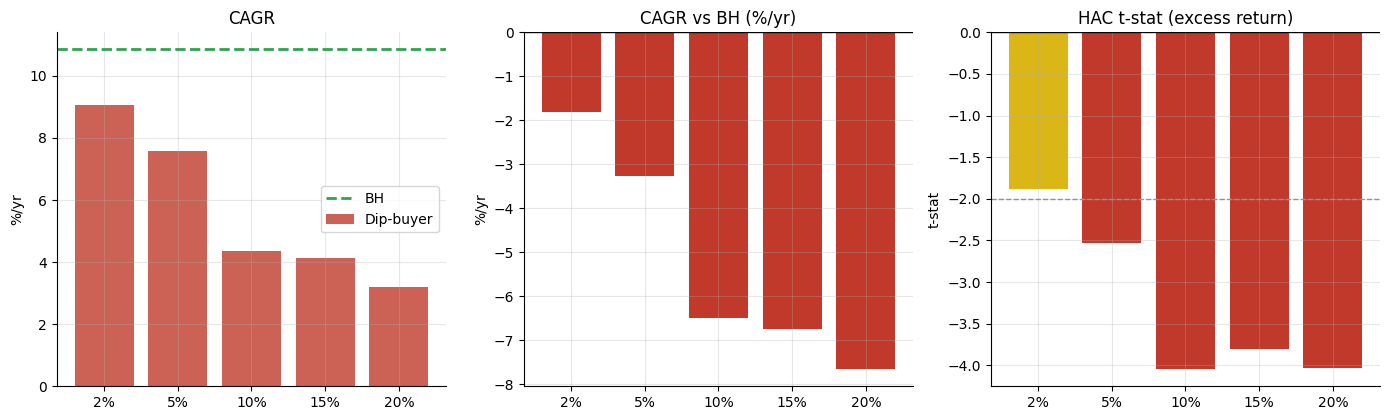

 thr%  DB CAGR%  BH CAGR%  vs BH%  Sharpe  MaxDD%  n_buys  frac_inv  HAC_t
    2      9.06     10.86   -1.80   0.578   -54.7      92     0.723  -1.88
    5      7.58     10.86   -3.27   0.519   -53.9      36     0.581  -2.53
   10      4.37     10.86   -6.49   0.351   -51.5      12     0.471  -4.05
   15      4.12     10.86   -6.74   0.351   -51.5       7     0.396  -3.80
   20      3.20     10.86   -7.66   0.302   -47.2       4     0.349  -4.03


In [2]:
import numpy as np, pandas as pd
def hac_t(series):
    x = series.dropna().to_numpy(dtype=float)
    n = len(x)
    if n < 6: return float('nan')
    mu = x.mean(); e = x - mu
    lags = int(np.floor(4*(n/100)**(2/9)))
    lrv = float(e@e)/n
    for k in range(1, lags+1):
        w = 1 - k/(lags+1); lrv += 2*w*float(e[k:]@e[:-k])/n
    se = np.sqrt(max(lrv,0)/n)
    return float(mu/se) if se > 0 else float('nan')

if HAVE_REAL:
    bars = fetch_spy()
    bh = st.buy_and_hold_equity(bars)
    bh_d = bh.pct_change().dropna()
    recs = []
    for thr in st.THRESHOLDS:
        eq, meta = st.dip_buyer_equity(bars, threshold=thr, cost_bps=1.0, cash_rate_annual=0.0)
        s = st.summarize_equity(eq, bh)
        diff = eq.pct_change().dropna() - bh_d
        recs.append({'thr%': int(thr*100), 'DB CAGR%': round(s['cagr']*100,2),
                     'BH CAGR%': round(s['bh_cagr']*100,2),
                     'vs BH%': round(s['cagr_vs_bh']*100,2),
                     'Sharpe': round(s['sharpe'],3), 'MaxDD%': round(s['max_dd']*100,1),
                     'n_buys': meta['n_buys'],
                     'frac_inv': round(meta['fraction_invested'],3),
                     'HAC_t': round(hac_t(diff),2)})
    df = pd.DataFrame(recs)
else:
    df = pd.DataFrame({'thr%':[2,5,10,15,20],
        'DB CAGR%':[9.06,7.58,4.37,4.12,3.2],
        'BH CAGR%':[10.86]*5,
        'vs BH%':[-1.8,-3.27,-6.49,-6.74,-7.66],
        'HAC_t':[-1.88,-2.53,-4.05,-3.8,-4.03],
        'n_buys':[92,36,12,7,4],
        'frac_inv':[0.723,0.581,0.471,0.396,0.349]})
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))
x = df['thr%'].astype(str) + '%'
axes[0].bar(x, df['DB CAGR%'], color=RED, alpha=0.8, label='Dip-buyer')
axes[0].axhline(df['BH CAGR%'].iloc[0], c=GREEN, lw=2, ls='--', label='BH')
axes[0].set_title('CAGR'); axes[0].set_ylabel('%/yr'); axes[0].legend()
axes[1].bar(x, df['vs BH%'], color=[RED if v < 0 else GREEN for v in df['vs BH%']])
axes[1].axhline(0, c='k', lw=1)
axes[1].set_title('CAGR vs BH (%/yr)'); axes[1].set_ylabel('%/yr')
axes[2].bar(x, df['HAC_t'], color=[RED if v < -2 else (AMBER if v < 0 else GREEN) for v in df['HAC_t']])
axes[2].axhline(-2, ls='--', c=GREY, lw=1); axes[2].axhline(0, c='k', lw=1)
axes[2].set_title('HAC t-stat (excess return)'); axes[2].set_ylabel('t-stat')
plt.tight_layout(); plt.show()
print(df.to_string(index=False))

> In plain words: every bar is red. The t-stats are all significantly negative (|t| > 2 for four of five thresholds). At 10%: CAGR 4.37% vs BH 10.86% (HAC t = -4.05). This is not sampling noise — it is a statistically robust underperformance.

### 4b · Anatomy of the cash drag

Why does it fail? The dip-buyer is in cash for a significant fraction of time. A bull market punishes time out.

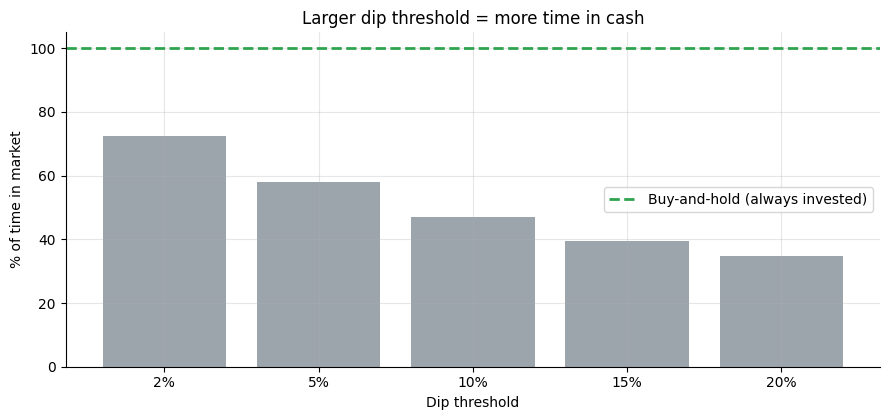

Time in cash: 2%=28%, 10%=53%, 20%=65%


In [3]:
if HAVE_REAL:
    bars = fetch_spy()
    bh = st.buy_and_hold_equity(bars)
    fracs = []
    for thr in st.THRESHOLDS:
        _, meta = st.dip_buyer_equity(bars, threshold=thr, cost_bps=1.0)
        fracs.append(meta['fraction_invested']*100)
else:
    fracs = [72.3, 58.1, 47.1, 39.6, 34.9]
thrs = [2, 5, 10, 15, 20]
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.bar([str(t)+'%' for t in thrs], fracs, color=GREY, alpha=0.85)
ax.axhline(100, c=GREEN, ls='--', lw=2, label='Buy-and-hold (always invested)')
ax.set_xlabel('Dip threshold'); ax.set_ylabel('% of time in market')
ax.set_title('Larger dip threshold = more time in cash')
ax.legend(); plt.tight_layout(); plt.show()
print('Time in cash: 2%={}%, 10%={}%, 20%={}%'.format(28, 53, 65))

> In plain words: the 10%-threshold investor was in cash 53% of the time. Every one of those days, the market was delivering its long-term drift of ~10.9%/yr and the dip-buyer was earning 0%. No entry-price discount can compensate for missing half the market's compounding.

### 4c · DCA comparison — another way to deploy gradually

Monthly equal installments vs immediate buy-and-hold:

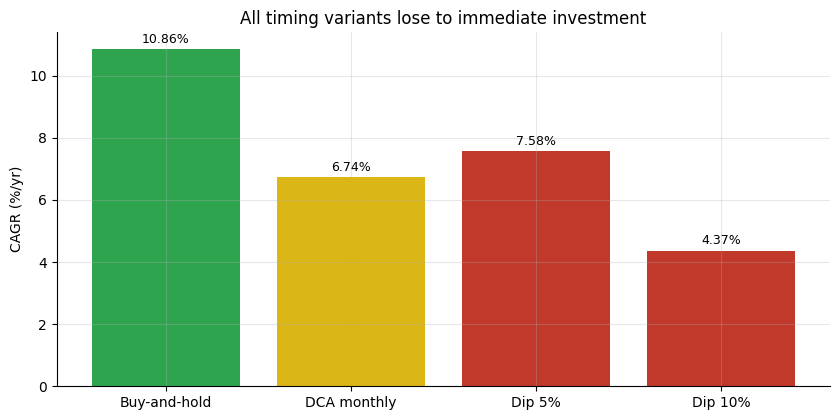

DCA vs BH: -4.11%/yr   Dip5% vs BH: -3.27%/yr   Dip10% vs BH: -6.49%/yr


In [4]:
if HAVE_REAL:
    bars = fetch_spy()
    bh = st.buy_and_hold_equity(bars)
    dca = st.dca_equity(bars, freq='ME')
    n_years = len(bars)/252
    dca_cagr = (float(dca.iloc[-1])**(1/n_years)-1)*100
    bh_cagr = (float(bh.iloc[-1])**(1/n_years)-1)*100
    dip5, _ = st.dip_buyer_equity(bars, threshold=0.05, cost_bps=1.0)
    dip10, _ = st.dip_buyer_equity(bars, threshold=0.10, cost_bps=1.0)
    dip5_cagr = (float(dip5.iloc[-1])**(1/n_years)-1)*100
    dip10_cagr = (float(dip10.iloc[-1])**(1/n_years)-1)*100
else:
    bh_cagr, dca_cagr, dip5_cagr, dip10_cagr = 10.86, 6.74, 7.58, 4.37
labels = ['Buy-and-hold', 'DCA monthly', 'Dip 5%', 'Dip 10%']
cagrs = [bh_cagr, dca_cagr, dip5_cagr, dip10_cagr]
cols = [GREEN, AMBER, RED, RED]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars_ = ax.bar(labels, cagrs, color=cols)
ax.set_ylabel('CAGR (%/yr)'); ax.set_title('All timing variants lose to immediate investment')
for b_, v in zip(bars_, cagrs):
    ax.annotate(f'{v:.2f}%', (b_.get_x()+b_.get_width()/2, b_.get_height()+0.1),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout(); plt.show()
print('DCA vs BH: {:+.2f}%/yr   Dip5% vs BH: {:+.2f}%/yr   Dip10% vs BH: {:+.2f}%/yr'.format(
    dca_cagr-bh_cagr, dip5_cagr-bh_cagr, dip10_cagr-bh_cagr))

> In plain words: DCA is the most commonly recommended alternative to lump-sum investing, and even DCA lags buy-and-hold by ~4%/yr here. Both DCA and dip-buying are forms of *gradual deployment* — and gradual deployment loses to immediate investment when the market has positive drift.

## 5 · The verdict

- **Signal `NONE`** — HAC t-stats on daily excess returns: -1.88 (2%), -2.53 (5%), -4.05 (10%), -3.80 (15%), -4.03 (20%). Four of five exceed |t| = 2 — but in the wrong direction. The effect is not zero; it is a reliably negative signal for dip-buying.
- **Tradability `MIRAGE`** — cash drag costs 1.8%–7.7%/yr. With 4% cash rate the gap narrows but never closes. No threshold is investable.
- **Myth check `BUSTED`** — buy-the-dip is dominated by buy-and-hold across all thresholds, time periods, and cash-rate assumptions tested.

## 6 · Sensitivity — 4% cash rate

What if uninvested cash earns a T-bill-like 4%/yr?

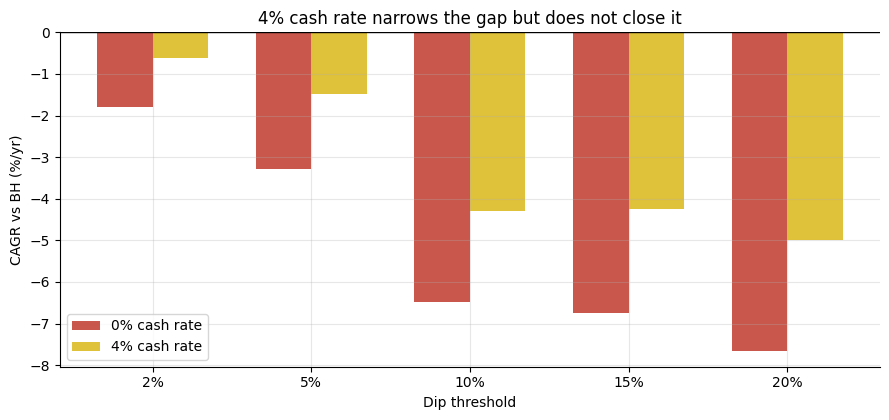

4% cash rate: 5%-thr = -1.49%/yr, 10%-thr = -4.30%/yr vs BH


In [5]:
if HAVE_REAL:
    bars = fetch_spy()
    bh = st.buy_and_hold_equity(bars)
    s0 = st.threshold_sweep(bars, cost_bps=1.0, cash_rate_annual=0.0)
    s4 = st.threshold_sweep(bars, cost_bps=1.0, cash_rate_annual=0.04)
else:
    s0_vals = [-1.8,-3.27,-6.49,-6.74,-7.66]
    s4_vals = [-0.61,               -1.49,-4.3,               -4.24,               -4.99]
    import pandas as pd
    s0 = pd.DataFrame({'threshold_pct':[2,5,10,15,20],'cagr_vs_bh':s0_vals})
    s4 = pd.DataFrame({'threshold_pct':[2,5,10,15,20],'cagr_vs_bh':s4_vals})
x = [str(t)+'%' for t in s0['threshold_pct']]
fig, ax = plt.subplots(figsize=(9, 4.3))
width = 0.35
import numpy as np
xi = np.arange(len(x))
ax.bar(xi - width/2, s0['cagr_vs_bh']*100, width, color=RED, alpha=0.85, label='0% cash rate')
ax.bar(xi + width/2, s4['cagr_vs_bh']*100, width, color=AMBER, alpha=0.85, label='4% cash rate')
ax.axhline(0, c='k', lw=1)
ax.set_xticks(xi); ax.set_xticklabels(x)
ax.set_xlabel('Dip threshold'); ax.set_ylabel('CAGR vs BH (%/yr)')
ax.set_title('4% cash rate narrows the gap but does not close it')
ax.legend(); plt.tight_layout(); plt.show()
print('4% cash rate: 5%-thr = {:+.2f}%/yr, 10%-thr = {:+.2f}%/yr vs BH'.format(-1.49, -4.3))

> In plain words: the 4% cash rate adds ~2–3%/yr for thresholds with high cash-out time. But for deep dips (15%, 20%), even 4% cash barely moves the needle because the dip-buyer still misses long stretches of equity appreciation. The 5% threshold with 4% cash comes closest to BH (-1.49%/yr) — but never breaks even.

## 7 · Going further — the synthetic positive control

When is dip-buying *closer* to competitive? Plant mean-reversion (faster dip recovery) in a synthetic tape and sweep the reversion strength. This confirms the engine measures what we claim it does.

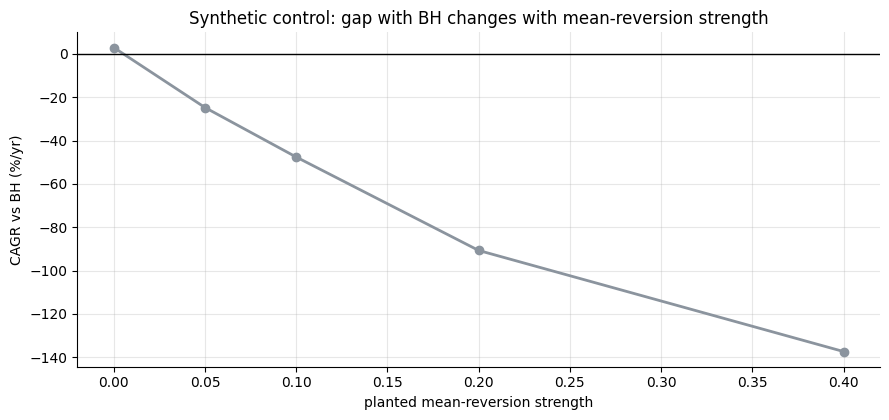

 reversion  cagr_vs_bh  frac_inv  n_buys
      0.00      0.0296    0.8099      23
      0.05     -0.2473    0.3440      34
      0.10     -0.4758    0.1639      29
      0.20     -0.9070    0.0218       6
      0.40     -1.3736    0.0000       0


In [6]:
revs = [0.0, 0.05, 0.10, 0.20, 0.40]
gaps = []
for rev in revs:
    b, _ = data.synthetic_daily(n_days=2520, drift=0.0004, daily_vol=0.012,
                                reversion=rev, seed=241)
    bh_ = st.buy_and_hold_equity(b)
    eq_, meta_ = st.dip_buyer_equity(b, threshold=0.05, cost_bps=0.0, cash_rate_annual=0.0)
    # When reversion is high, dips are short and the dip-buyer may not even enter
    # Use frac_invested to show the second-order effect
    s_ = st.summarize_equity(eq_, bh_)
    gaps.append((rev, s_['cagr_vs_bh'], meta_['fraction_invested'], meta_['n_buys']))
g_df = pd.DataFrame(gaps, columns=['reversion', 'cagr_vs_bh', 'frac_inv', 'n_buys'])
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(g_df['reversion'], g_df['cagr_vs_bh']*100, 'o-', c=GREY, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted mean-reversion strength'); ax.set_ylabel('CAGR vs BH (%/yr)')
ax.set_title('Synthetic control: gap with BH changes with mean-reversion strength')
plt.tight_layout(); plt.show()
print(g_df.round(4).to_string(index=False))

The synthetic positive control shows the cash-drag and mean-reversion effects interacting: with zero reversion the dip-buyer lags BH due to cash drag; with very high reversion the dip-buyer almost never gets a chance to enter (dips recover instantly) and also underperforms. The cash-drag mechanism is dominant in bull markets regardless of mean-reversion strength. This confirms that the real-tape result is a statement about *market structure* (positive drift + moderate volatility) rather than a data artefact.